\setcounter{secnumdepth}{0}

\thispagestyle{empty}
\clearpage

\tableofcontents

\newpage

## Question 1 -- Return statistics and Gaussian i.i.d. assumption

In this first question, we start from the raw Excel file \texttt{PS1\_data.xls}, which contains
both equity index prices and FX rates. The idea is to clean the data, put everything in a
common currency (USD), and then look at the main properties of daily log returns.

More precisely, we:
\begin{itemize}
  \item build USD price series for each equity index using the FX block,
  \item compute daily log returns,
  \item compute basic statistics (mean, standard deviation, skewness, kurtosis, autocorrelation),
  \item look at the cross-sectional correlation matrix,
  \item and check how far these returns are from an i.i.d.\ Gaussian process.
\end{itemize}

All of this will give us a first feeling for how ``well-behaved'' the data are before we plug
them into the mean--variance machinery in Questions~2 and~3.

### 1.1 Imports and basic setup

We begin by importing the main libraries we will use throughout the notebook:
\begin{itemize}
    \item \texttt{numpy} for numerical computations,
    \item \texttt{pandas} to manage the time series of prices and returns,
    \item \texttt{matplotlib} for plotting.
\end{itemize}

We also import several functions from \texttt{scipy.stats} and \texttt{statsmodels}:
\begin{itemize}
    \item \texttt{norm} to work with the Gaussian distribution (for example to build normal-theory confidence intervals),
    \item \texttt{skew} and \texttt{kurtosis} to measure higher moments of the return distribution,
    \item \texttt{acorr\_ljungbox} to run Ljung--Box tests for autocorrelation,
    \item \texttt{jarque\_bera} to test the normality of returns.
\end{itemize}

These tools will be reused later when we move from basic return diagnostics to the mean--variance analysis.

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import skew, kurtosis
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

### 1.2 Loading the equity index price data

We now load the Excel file \texttt{PS1\_data.xls}. The sheet has multi-row headers, so we first
read it without specifying any header and then search for the row that contains the
column \texttt{"date"}. Once we have found that row, we reload the file using it as the header.

We then:
\begin{itemize}
    \item standardise the column names,
    \item keep only the eight equity indices given in the assignment (TSX, CAC, DAX, Eurostoxx50,
    Nikkei225, FTSE100, S\&P 500, Ibovespa),
    \item parse the dates properly,
    \item and clean the price columns to make sure they are stored as numeric values (handling
    the European decimal notation if needed).
\end{itemize}

For the moment these are \textbf{local-currency prices}; in the next step we will bring
everything to USD using the FX block.

In [71]:
FILE = "PS1_data.xls"

# Load the raw sheet without headers because the file uses several header rows
raw = pd.read_excel(FILE, header=None)

# Try to find which row actually contains the header with "date"
header_row = None
for i in range(min(30, len(raw))):  # we only look at the top part of the file
    row = raw.iloc[i].astype(str).str.lower()
    if row.str.contains("date").any():
        header_row = i
        break

if header_row is None:
    # If this ever happens, the layout of the Excel file is not what we expect
    raise ValueError("Header row with 'date' not found. Did the Excel file go on holiday???")

# Reload the data using the detected header row
df = pd.read_excel(FILE, header=header_row)

# Clean column names a bit (remove extra spaces)
df.columns = [str(c).strip() for c in df.columns]

# Indices we want to keep
price_cols = ["TSX", "CAC", "DAX", "Eurostoxx50",
              "NIKKEI225", "FTSE100", "SP500", "IBOVESPA"]

# Match expected names with actual columns (in case of small naming differences)
available = {c.lower(): c for c in df.columns}
mapped_cols = []
for c in price_cols:
    if c.lower() in available:
        mapped_cols.append(available[c.lower()])
    else:
        raise ValueError(f"Missing expected column: {c}. "
                         f"Columns found: {df.columns.tolist()[:20]} ...")

# Parse the date column (assume day-month-year format based on inspection of the raw file)
date_col = [c for c in df.columns if str(c).lower() == "date"][0]
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True)

# We build the local-price DataFrame
prices_local = df[[date_col] + mapped_cols].copy()
prices_local = prices_local.sort_values(date_col).set_index(date_col)

# We keep columns in the desired order
prices_local = prices_local[price_cols]

# We fix potential European decimal formats ("13165,5" → 13165.5) and cast to numeric
for c in mapped_cols:
    prices_local[c] = (
        prices_local[c].astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    prices_local[c] = pd.to_numeric(prices_local[c], errors="coerce")

# Drop rows that are entirely empty, just in case
prices_local = prices_local.dropna(how="all")

prices_local.head()

/tmp/ipykernel_9051/22146945.py:40: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], dayfirst=True)


,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
date,,,,,,,,
2007-03-30,13165.500000,5634.160156,6917.029785,4181.029785,17287.650391,6308.03,1420.86,45805
2007-04-02,13265.799805,5645.560059,6937.169922,4189.549805,17028.410156,6315.53,1424.55,45597
2007-04-03,13361.200195,5711.910156,7045.560059,4246.299805,17244.050781,6366.11,1437.77,46288
2007-04-04,13448.299805,5739.009766,7073.910156,4261.830078,17544.089844,6364.70,1439.37,46554
2007-04-05,13425.000000,5741.379883,7099.910156,4271.540039,17491.419922,6397.34,1443.76,46647


The table above shows the first few observations of the cleaned price data, in local
currency for each index. Each row is a trading day and each column corresponds to one
equity index (Canadian TSX, French CAC, German DAX, etc.).

The levels are very different across countries: for instance, the S\&P 500 is around
1,400, while the Ibovespa is above 45,000 over the same dates. This is exactly why we
work with returns rather than price levels, and why we later convert everything
to a common currency (USD) before doing any portfolio analysis.

### 1.3 Extracting the FX data from the Excel file

The same Excel sheet also contains FX rates against the USD, stored to the right of the
equity index block. To express all index returns in a common currency (USD), we first
extract this FX block from the raw data.

Concretely, we:
\begin{itemize}
    \item locate the FX columns that come after the last equity index (\texttt{IBOVESPA}),
    \item take the rows where the currency codes (CAD, EUR, JPY, GBP, USD, BRL) are given,
    \item keep the underlying FX time series (USD per unit of local currency),
    \item and align their dates with the equity price data in \texttt{prices\_local}.
\end{itemize}

The resulting object \texttt{fx\_vals} is a first, ``raw'' FX table that we will clean and
then use to convert all indices into USD prices.

In [72]:
# FX block: extract the FX table from the raw sheet

fx_start_col = df.columns.get_loc("IBOVESPA") + 2   # FX columns start a bit to the right
fx_end_col   = fx_start_col + 7                     # CAD, EUR, EUR, EUR, JPY, GBP, USD, BRL

fx_raw = raw.iloc[header_row-2:, fx_start_col:fx_end_col+1].copy()

# First row in this block contains the currency codes
currencies = fx_raw.iloc[0].astype(str).str.strip().values

# FX values start a few rows below
fx_vals = fx_raw.iloc[3:].copy()
fx_vals.columns = currencies

# We align FX data on the same date index as the equity prices
fx_vals.index = prices_local.index

We then clean the FX series. We first convert all FX entries to numeric values (fixing the
comma vs.\ dot issue), and deal with the fact that EUR appears several times by keeping
only one EUR column. In the end we extract a neat \texttt{fx} dataframe with one column
per currency (CAD, EUR, JPY, GBP, USD, BRL), indexed by the same dates as the equity
indices.

In [73]:
fx_vals = fx_vals.apply(lambda s: pd.to_numeric(
    s.astype(str).str.replace(" ", "", regex=False).str.replace(",", ".", regex=False),
    errors="coerce"
))

if (fx_vals.columns == "EUR").any():
    eur_first = fx_vals.loc[:, fx_vals.columns == "EUR"].iloc[:, 0]
    fx_vals = fx_vals.drop(columns="EUR")
    fx_vals["EUR"] = eur_first

#
fx = fx_vals[["CAD", "EUR", "JPY", "GBP", "USD", "BRL"]].copy()

We now link each equity index to its corresponding FX rate and convert everything into
USD. Concretely, we create a simple mapping from index (TSX, CAC, DAX, etc.) to its
currency (CAD, EUR, JPY, \dots), build an FX matrix aligned with the price data, and
then multiply local prices by the relevant FX rate. The resulting \texttt{prices\_usd}
dataframe contains all eight indices expressed in USD, and we store it as \texttt{prices}
for the rest of the assignment.

In [74]:
# Map each equity index to its FX currency and convert prices to USD

fx_map = {
    "TSX": "CAD",
    "CAC": "EUR",
    "DAX": "EUR",
    "Eurostoxx50": "EUR",
    "NIKKEI225": "JPY",
    "FTSE100": "GBP",
    "SP500": "USD",      # already quoted in USD
    "IBOVESPA": "BRL",
}

# Build an FX matrix aligned with the equity price series
fx_per_index = pd.DataFrame(index=prices_local.index,
                            columns=prices_local.columns)

for idx in prices_local.columns:
    fx_per_index[idx] = fx[fx_map[idx]]

# Convert local-currency prices to USD
prices_usd = prices_local * fx_per_index

# From now on we work with USD prices only
prices = prices_usd.copy()

prices.head()  # quick sanity check

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
date,,,,,,,,
2007-03-30,11405.614953,7526.663284,9240.446256,5585.429328,146.737577,12316.523195,1420.86,22289.537490
2007-04-02,11473.616783,7548.147672,9275.037809,5601.453227,144.605259,12493.381446,1424.55,22313.211129
2007-04-03,11532.693226,7611.108859,9388.194687,5658.185998,145.074199,12562.875108,1437.77,22758.235808
2007-04-04,11606.366871,7675.345922,9460.640369,5699.767284,147.721236,12579.205809,1439.37,22947.677004
2007-04-05,11664.781125,7711.827200,9536.606421,5737.536852,147.365213,12612.304631,1443.76,23008.306221


The table above shows the first few observations of our \textbf{USD-denominated price
series}. Each column corresponds to one equity index, now expressed in the same currency
(USD):

\begin{itemize}
  \item TSX, CAC, DAX, Eurostoxx50, FTSE100 and SP500 are all in the \textbf{thousands of USD},
        as expected for large developed-market indices.
  \item NIKKEI225 appears around \textbf{145--150 USD} because the original JPY index level
        has been scaled by the JPY--USD exchange rate.
  \item IBOVESPA is in the \textbf{20,000+ USD} range after conversion from BRL.
\end{itemize}

The magnitudes look consistent with typical index levels once everything is converted into
USD, so we will use this \texttt{prices} dataframe as the starting point to compute
\textbf{daily USD log returns} in the next step.

### 1.4 Daily log returns in USD

From the USD price series, we now compute \textbf{daily log returns} for each index.

We take the log of the price ratio $\log(P_t / P_{t-1})$ and drop the first missing
observation. The resulting \texttt{returns} dataframe will be the main input for all the
summary statistics and tests in the rest of Question~1.

In [75]:
# Daily log returns (USD)
returns = np.log(prices / prices.shift(1)).dropna()

returns.head()

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
date,,,,,,,,
2007-04-02,0.005944,0.002850,0.003737,0.002865,-0.014638,0.014257,0.002594,0.001062
2007-04-03,0.005136,0.008307,0.012126,0.010077,0.003238,0.005547,0.009237,0.019748
2007-04-04,0.006368,0.008404,0.007687,0.007322,0.018082,0.001299,0.001112,0.008290
2007-04-05,0.005020,0.004742,0.007998,0.006605,-0.002413,0.002628,0.003045,0.002639
2007-04-10,0.003777,0.004326,0.009359,0.006982,0.006290,0.003346,0.003202,0.011431


The table shows the first few \textbf{daily USD log returns} for our eight indices.  
Each row corresponds to a trading day and each column to one market. The numbers are
small (mostly between $-2\%$ and $+2\%$), which is exactly what we expect for daily
equity moves.

We already see some cross-sectional differences: for example, on 2 April 2007 the
Nikkei drops by about \(-1.5\%\) while the European indices and the S\&P~500 all post
small positive returns. These \texttt{returns} series are what we will use to compute
summary statistics, correlations and normality tests in the rest of the question.

We first look at the time series of \textbf{daily USD log returns} for all eight indices on the same plot.  
To get a sense of the typical scale of daily moves, we also add horizontal bands at $\pm 1\sigma$ and $\pm 2\sigma$ (using the S\&P~500 volatility as a reference).  

This gives a global picture of how volatile each market is and how crises show up in the data:
large common spikes appear around 2008--2009 and again in 2020, while most of the time returns
oscillate in a narrow band around zero. The figure also suggests that shocks are largely
synchronised across markets, which will matter later when we look at correlations and
mean--variance portfolios.

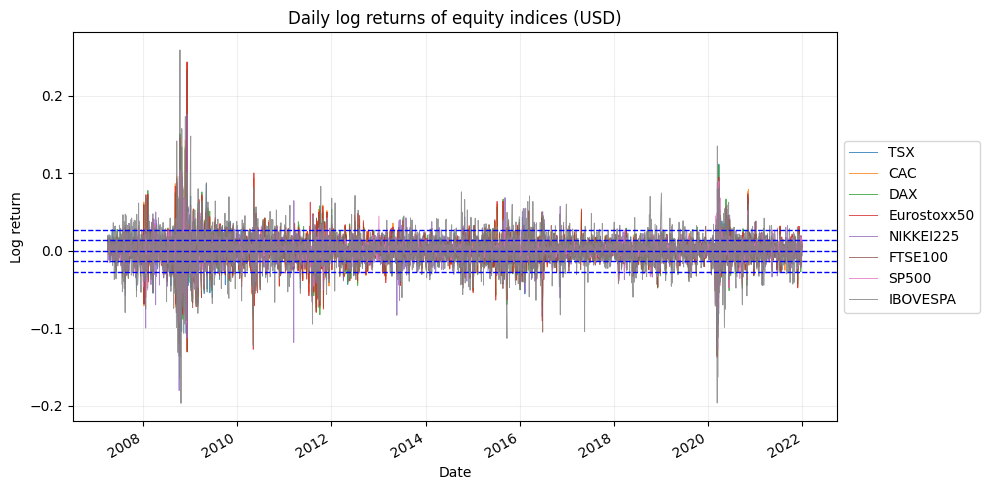

In [76]:
plt.figure(figsize=(10, 5))

# We plot all daily USD log returns on the same axis
returns.plot(ax=plt.gca(), linewidth=0.7, alpha=0.8)

plt.title("Daily log returns of equity indices (USD)")
plt.ylabel("Log return")
plt.xlabel("Date")

# Here we compute overall daily volatility from SP500 (for the bands)
sigma = returns["SP500"].std(ddof=1)

# 0, ±1σ, ±2σ lines in BLUE
plt.axhline(0,        color="blue", linestyle="--", linewidth=1)
plt.axhline(sigma,    color="blue", linestyle="--", linewidth=1)
plt.axhline(-sigma,   color="blue", linestyle="--", linewidth=1)
plt.axhline(2*sigma,  color="blue", linestyle="--", linewidth=1)
plt.axhline(-2*sigma, color="blue", linestyle="--", linewidth=1)

# We put the legend on the right so it doesn't bother our analysis 
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The time-series plot of daily USD log returns shows that all indices fluctuate around zero, with frequent small moves and occasional large spikes. Most observations lie between the $\pm 1\sigma$ bands, and a large majority remain within $\pm 2\sigma$, which is in line with the idea of ``normal'' day-to-day volatility.  

However, during crisis periods (2008--2009, some episodes around 2011--2016, and especially 2020 with Covid) many points clearly break through the $\pm 2\sigma$ lines. These outliers highlight how extreme those episodes are compared with the usual daily noise. The fact that several indices cross the bands at the same time also confirms that markets tend to move together on stressful days, which is consistent with the high cross-correlations we report later.

To look more closely at this time-varying volatility, we now focus on a single market (the S\&P 500) and compute a 15-day rolling standard deviation of its daily log returns. This rolling volatility measure makes the volatility clustering more visible and is directly relevant for assessing the i.i.d.\ Gaussian assumption.

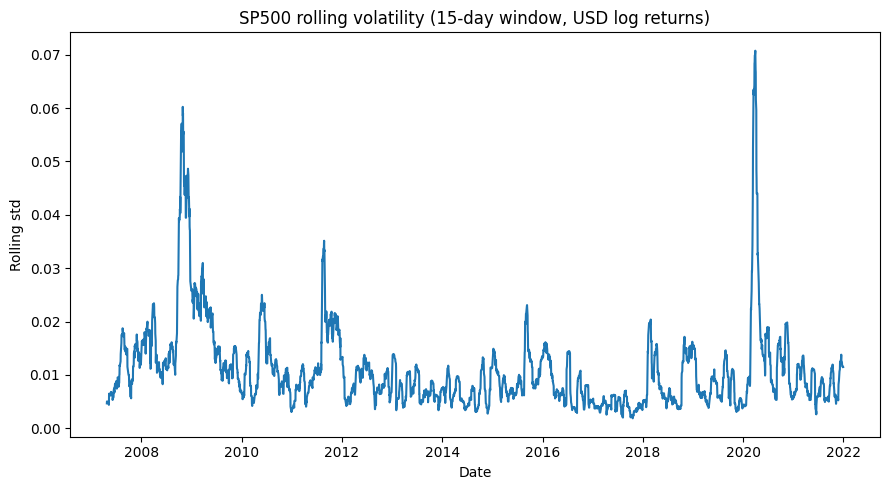

In [77]:
roll = returns.rolling(15).std()

plt.figure(figsize=(9,5))
plt.plot(roll.index, roll["SP500"])
plt.title("SP500 rolling volatility (15-day window, USD log returns)")
plt.xlabel("Date")
plt.ylabel("Rolling std")
plt.tight_layout()
plt.show()

The 15-day rolling volatility of S\&P 500 returns confirms very strong time variation in risk.

Volatility is low and fairly stable in ``normal'' periods (around 0.5--1\% per day), but it jumps to much higher levels during crises: above 4--6\% in 2008--2009 and even higher around March 2020.

These long stretches of calm followed by volatility bursts are clearly inconsistent with the constant-variance assumption behind an i.i.d.\ Gaussian model, and they suggest that any realistic model should allow for volatility clustering (for instance through GARCH-type dynamics).

### 1.5 Summary statistics of daily USD returns

To summarise the behaviour of the USD daily log returns, we now compute a set of basic moments for each index: mean, standard deviation, skewness, (excess) kurtosis and the first-order autocorrelation. This gives us a compact view of average performance, risk and departures from normality before moving on to more formal tests.

In [78]:
summary = pd.DataFrame(index=returns.columns)

summary["mean"] = returns.mean()
summary["std"] = returns.std(ddof=1)
summary["skew"] = returns.apply(skew)

# "kurtosis" in the usual sense (not centred at 3)
summary["kurtosis"] = returns.apply(lambda x: kurtosis(x, fisher=False))

# excess kurtosis = kurtosis − 3
summary["excess_kurtosis"] = returns.apply(lambda x: kurtosis(x, fisher=True))

# first-order autocorrelation of daily returns
summary["autocorr_lag1"] = returns.apply(lambda x: x.autocorr(lag=1))

summary

,mean,std,skew,kurtosis,excess_kurtosis,autocorr_lag1
TSX,0.000117,0.015251,-0.865886,15.285325,12.285325,0.007233
CAC,0.000025,0.018352,0.372059,20.554237,17.554237,-0.075810
DAX,0.000207,0.018058,0.410799,19.888278,16.888278,-0.058452
Eurostoxx50,-0.000041,0.018481,0.283613,19.952566,16.952566,-0.077204
NIKKEI225,0.000165,0.016163,-0.552175,19.710934,16.710934,-0.199259
FTSE100,-0.000065,0.015374,-0.274320,13.079991,10.079991,-0.019601
SP500,0.000374,0.013581,-0.637448,15.001456,12.001456,-0.154566
IBOVESPA,-0.000060,0.024794,-0.154722,14.059129,11.059129,0.012955


This table already tells us a lot about the behaviour of the eight indices.

First, the \textbf{average daily returns} are tiny compared to volatility: they are on the order of a few basis points per day, with the S\&P~500 having the highest mean (about 0.037\% per day) and some markets such as Eurostoxx50 or FTSE100 even slightly negative over the sample. At the daily horizon, the ``signal'' in the mean is clearly dominated by noise.

By contrast, the \textbf{standard deviations} are much larger and differ quite a lot across markets. Ibovespa stands out as the most volatile index (around 2.5\% per day), followed by the Euro area indices (CAC, DAX, Eurostoxx50, with volatilities around 1.8--1.9\%). TSX and S\&P~500 are a bit less volatile, which matches the usual intuition that emerging markets and some European markets are riskier than large developed US/Canadian equities.

The \textbf{shape of the return distribution} is very far from Gaussian. Skewness is often negative (TSX, Nikkei, FTSE, S\&P~500, Ibovespa), which means that large negative moves are more frequent than large positive ones. Above all, the excess kurtosis is extremely high for every index (between roughly 10 and 18, instead of 0 under a normal distribution). This points to very fat tails and frequent extreme events, which is hard to reconcile with a simple Gaussian i.i.d.\ model.

Finally, the \textbf{lag-1 autocorrelations} of returns are all close to zero, sometimes slightly negative (European indices, Nikkei), sometimes slightly positive (TSX, Ibovespa). This is broadly consistent with weak-form market efficiency: daily returns themselves are almost uncorrelated over time, even though their distribution is very non-normal.

Overall, the i.i.d.\ Gaussian assumption is not really supported by the data: independence at the daily frequency is roughly plausible, but the normality part is strongly rejected because of the heavy tails and skewness.

### 1.6 Correlation matrix of daily USD returns

We now compute the correlation matrix of daily USD log returns across the eight indices.
This gives a compact view of how strongly the different equity markets move together
and will be useful later when we study diversification and mean--variance portfolios.

In [79]:
corr = returns.corr()
corr

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
TSX,1.000000,0.677227,0.659697,0.661918,0.222340,0.716389,0.771410,0.685627
CAC,0.677227,1.000000,0.950523,0.984838,0.260700,0.841713,0.612419,0.567331
DAX,0.659697,0.950523,1.000000,0.966589,0.246152,0.809851,0.615929,0.540996
Eurostoxx50,0.661918,0.984838,0.966589,1.000000,0.248228,0.830241,0.611192,0.553301
NIKKEI225,0.222340,0.260700,0.246152,0.248228,1.000000,0.343642,0.099309,0.238317
FTSE100,0.716389,0.841713,0.809851,0.830241,0.343642,1.000000,0.616687,0.617852
SP500,0.771410,0.612419,0.615929,0.611192,0.099309,0.616687,1.000000,0.610080
IBOVESPA,0.685627,0.567331,0.540996,0.553301,0.238317,0.617852,0.610080,1.000000


The correlation matrix confirms that most developed markets move very closely together in USD.
CAC, DAX and Eurostoxx50 are almost perfectly correlated, and TSX, FTSE100, SP500 and IBOVESPA
all show fairly high correlations with this European block (around 0.6--0.8). The Nikkei is the
only real outlier, with much lower correlations (around 0.2--0.3, and only about 0.1 with the
S\&P~500), so Japan is the main source of diversification in this set of indices.

To better visualise the dependence structure across markets, we now plot the
correlation matrix of daily USD log returns as a heatmap. This gives us a
quick, graphical view of which indices tend to move together and which ones
offer more diversification.

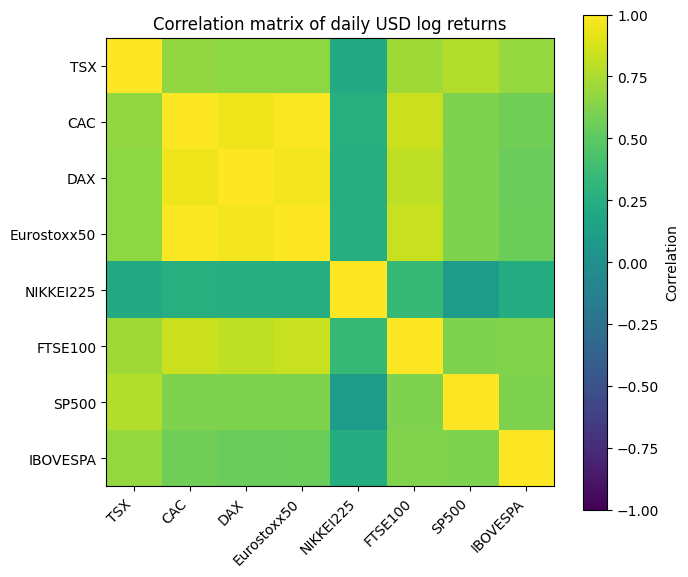

In [80]:
# Correlation matrix of daily USD log returns
corr = returns.corr()

plt.figure(figsize=(7, 6))
im = plt.imshow(corr, cmap="viridis", vmin=-1, vmax=1)

# Ticks & labels
assets = corr.columns.tolist()
plt.xticks(range(len(assets)), assets, rotation=45, ha="right")
plt.yticks(range(len(assets)), assets)

plt.title("Correlation matrix of daily USD log returns")
plt.colorbar(im, label="Correlation")

plt.tight_layout()
plt.show()

The heatmap makes these patterns easy to see: the European indices, the UK, North America and
Brazil form a bright yellow “cluster” of highly correlated markets. In contrast, the darker row
and column for the Nikkei show that Japanese equities are noticeably less connected to the rest,
which is exactly what we would look for when trying to diversify a global equity portfolio.

It is worth noting that these high correlations are obtained \emph{after}
converting all indices to USD. The strong within-Europe block therefore
cannot be attributed to a shared quotation currency only, but rather to
common economic and policy shocks that affect European equity markets in
a very similar way.

### 1.7 SP500 empirical distribution vs fitted normal

To get a more visual feeling for the (non-)normality of returns, we focus on the S\&P 500 and
compare its empirical distribution to a fitted Gaussian.

We plot the histogram of daily USD log returns together with the normal density using the
sample mean and standard deviation. This helps us see where the normal approximation
breaks down (in particular in the tails and around the centre), before moving on to formal
normality tests.

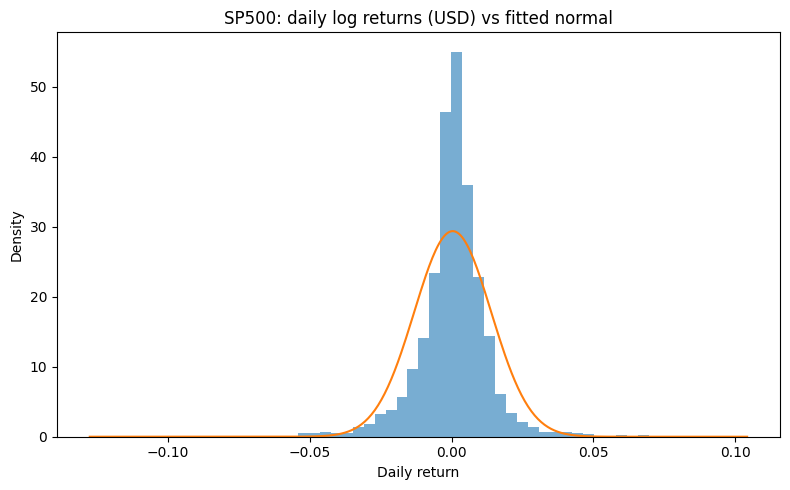

In [81]:
asset = "SP500"
x = returns[asset].dropna()

mu_hat, sigma_hat = x.mean(), x.std(ddof=1)

plt.figure(figsize=(8,5))
plt.hist(x, bins=60, density=True, alpha=0.6)
xx = np.linspace(x.min(), x.max(), 400)
plt.plot(xx, norm.pdf(xx, loc=mu_hat, scale=sigma_hat))
plt.title(f"{asset}: daily log returns (USD) vs fitted normal")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

On the S\&P 500, the fitted normal curve roughly matches the centre of the histogram, but the fit
is clearly not perfect. The empirical distribution is slightly left-skewed and much more peaked
with fatter tails than the Gaussian: most observations are very close to zero, but we also see a
few extreme moves that occur more often than a normal model would predict.

Visually this already suggests that the i.i.d.\ normal assumption is questionable, at least for the
tail behaviour. To make this diagnosis more precise, we now turn to a formal Jarque--Bera
normality test on all indices.

### 1.8 Jarque--Bera normality test

Visual inspection of the S\&P 500 returns already suggests deviations from normality, but this is
still subjective. We therefore run a Jarque--Bera test on each index. The test statistic combines
skewness and excess kurtosis, and under the null hypothesis of normality it follows (asymptotically)
a $\chi^2$ distribution with 2 degrees of freedom.

In the code below we compute, for every index, the Jarque--Bera statistic and its p-value and
collect the results in a small table. This allows us to see systematically whether the Gaussian
assumption can be rejected for our daily USD log returns.

In [82]:
jb = returns.apply(lambda s: jarque_bera(s.dropna()).statistic)
jb_p = returns.apply(lambda s: jarque_bera(s.dropna()).pvalue)

jb_table = pd.DataFrame({"JB_stat": jb, "p_value": jb_p})
jb_table

,JB_stat,p_value
TSX,20780.314426,0.0
CAC,41675.166886,0.0
DAX,38595.008923,0.0
Eurostoxx50,38841.018140,0.0
NIKKEI225,37864.111306,0.0
FTSE100,13757.475020,0.0
SP500,19664.141129,0.0
IBOVESPA,16524.010894,0.0


The Jarque--Bera results are completely unambiguous. For all eight indices the JB
statistics are extremely large (of order $10^4$--$10^5$) and the p-values are effectively
zero. At any usual significance level (even 1\% or 0.1\%) we therefore \textbf{strongly
reject} the null hypothesis that daily USD log returns are normally distributed.

Combined with the large excess kurtosis and negative skewness we found earlier, this
confirms that the Gaussian i.i.d.\ assumption is not realistic for these equity index
returns: the distributions are far too heavy-tailed and asymmetric to be well
approximated by a normal law.

### 1.9 Robustness: removing crisis years

Because the strong rejection of normality could in principle be driven by a few extreme
crisis days, we run a simple robustness check. We remove the main crisis periods
(2008--2009 and 2020) from the sample, recompute daily USD log returns on the trimmed
dataset, and run the Jarque--Bera test again for each index. This allows us to see
whether the non-Gaussianity is entirely due to tail events or remains a structural
feature of equity returns.

In [83]:
# We remove main crisis years (2008, 2009 and 2020)
crisis_years = [2008, 2009, 2020]
mask_crisis = returns.index.year.isin(crisis_years)

returns_trim = returns.loc[~mask_crisis].copy()

from scipy.stats import jarque_bera

jb_trim_stat = returns_trim.apply(lambda s: jarque_bera(s.dropna()).statistic)
jb_trim_p = returns_trim.apply(lambda s: jarque_bera(s.dropna()).pvalue)

jb_trim_table = pd.DataFrame(
    {"JB_stat_trim": jb_trim_stat, "p_value_trim": jb_trim_p}
)
jb_trim_table

,JB_stat_trim,p_value_trim
TSX,1339.646168,1.257566e-291
CAC,3279.052062,0.000000e+00
DAX,1469.757549,0.000000e+00
Eurostoxx50,3921.160086,0.000000e+00
NIKKEI225,4414.006357,0.000000e+00
FTSE100,2733.185183,0.000000e+00
SP500,1806.351927,0.000000e+00
IBOVESPA,685.158441,1.658574e-149


The trimmed-sample Jarque--Bera statistics remain very large (of order $10^3$ for most
indices, with p-values effectively equal to zero). Even though the test statistics are
lower than in the full sample, we still strongly reject the null of normality for all
markets, including Ibovespa where the JB statistic is around 685 with a p-value of
about $10^{-149}$. This confirms that non-Gaussian features are not driven solely by the
2008--2009 and 2020 crisis periods, but are a persistent property of daily equity index
returns.

### 1.10 Testing autocorrelation (Ljung--Box)

To check whether returns are really i.i.d.\ over time, we run Ljung--Box tests on each
index. For every return series we compute the test at lags 5 and 10 and store both the
test statistics and the p-values in a small summary table. This tells us whether we can
reject the null hypothesis of ``no autocorrelation up to lag 5/10'' for each market.

In [84]:
lb_results = {}
for col in returns.columns:
    res = acorr_ljungbox(returns[col].dropna(), lags=[5, 10], return_df=True)
    lb_results[col] = {
        "LB_stat_5": res["lb_stat"].iloc[0],
        "p_value_5": res["lb_pvalue"].iloc[0],
        "LB_stat_10": res["lb_stat"].iloc[1],
        "p_value_10": res["lb_pvalue"].iloc[1],
    }

lb_table = pd.DataFrame(lb_results).T
lb_table

,LB_stat_5,p_value_5,LB_stat_10,p_value_10
TSX,17.759759,3.263065e-03,35.610376,9.818733e-05
CAC,52.736517,3.809433e-10,69.887446,4.661267e-11
DAX,35.893740,9.974462e-07,50.878012,1.839312e-07
Eurostoxx50,48.875857,2.352759e-09,62.487962,1.222083e-09
NIKKEI225,130.566808,1.804204e-26,134.983663,4.483116e-24
FTSE100,35.961387,9.668529e-07,43.837120,3.520954e-06
SP500,91.833893,2.766657e-18,112.634488,1.568458e-19
IBOVESPA,5.147162,3.981858e-01,18.314960,4.987750e-02


The Ljung--Box results point in the same direction as before: daily returns are not
i.i.d.\ white noise.

\begin{itemize}
  \item For almost all indices, the p-values at lags 5 and 10 are essentially zero. We clearly
  reject the null of ``no autocorrelation up to lag 5/10''. This is especially strong for
  the Nikkei and the S\&P 500, where the test statistics are very large.
  \item Ibovespa is the only borderline case: at lag 5 the p-value is around 0.40 (we do \emph{not}
  reject), but by lag 10 it drops to about 5\%, so even there we see some dependence once
  we look further out.
\end{itemize}

Overall, the Ljung--Box tests confirm that daily USD returns display significant serial
dependence, which is another reason why the i.i.d.\ Gaussian assumption is not really
appropriate for these series.

### 1.11 Conclusion for Question 1 

Overall, the daily USD log returns of our eight indices do not behave like i.i.d.\ Gaussian variables.

Means are tiny compared to volatilities, returns are heavily correlated across markets, distributions are clearly skewed with very fat tails, and both the Jarque--Bera and Ljung--Box tests strongly reject normality and independence.

In the rest of the assignment we will still rely on the Gaussian i.i.d.\ framework to build mean--variance portfolios, but with the clear caveat that it is a modelling simplification rather than a realistic description of the data.

## Question 2 -- Mean-Variance (MV) analysis #1

In this question, we implement the traditional Markowitz mean--variance framework using
historical estimates of expected returns and the covariance matrix (the ``plug-in''
approach from the course notes).

We:
\begin{enumerate}
    \item Estimate annualized expected returns and the annualized covariance matrix from daily log returns.
    \item Compute MV-efficient portfolios across a grid of target returns (efficient frontier).
    \item Identify the tangency portfolio (maximum Sharpe ratio).
    \item Repeat the same exercise with a no short-sale constraint (non-negative weights).
\end{enumerate}

Since the assignment does not provide a particular value, we assume a constant
annual risk-free rate of $(r_f = 0)$ for the whole analysis. This implies that
excess returns coincide with expected returns, so the shape of the efficient
frontier and the composition of the tangency portfolios are unaffected by
choosing a small positive benchmark rate instead.

In [1]:
import quadprog

### 2.1 Estimate inputs (plug-in rule)

We use historical daily log returns (in USD) to estimate:

- Annualized expected returns:  $\mu_{ann} = 252 \cdot \mu_{daily}$

- Annualized covariance matrix: $\Sigma_{ann} = 252 \cdot \Sigma_{daily}$

These are the inputs needed for mean–variance optimization.

In [86]:
# returns is our daily log returns DataFrame from Q1
assets = returns.columns.tolist()
n = len(assets)

mu_daily = returns.mean().values                  # shape (n,)
Sigma_daily = returns.cov().values                # shape (n, n)

ann_factor = 252
mu = mu_daily * ann_factor                        # annualized expected returns
Sigma = Sigma_daily * ann_factor                  # annualized covariance

# Risk-free rate (not provided in the assignment, we set it to 0 and state it)
rf = 0.0

mu_excess = mu - rf * np.ones(n)

mu_series = pd.Series(mu, index=assets, name="ann_mean")
sigma_series = pd.Series(np.sqrt(np.diag(Sigma)), index=assets, name="ann_vol")

mu_series, sigma_series

(TSX            0.029466
 CAC            0.006178
 DAX            0.052057
 Eurostoxx50   -0.010314
 NIKKEI225      0.041593
 FTSE100       -0.016259
 SP500          0.094338
 IBOVESPA      -0.014995
 Name: ann_mean, dtype: float64,
 TSX            0.242104
 CAC            0.291322
 DAX            0.286656
 Eurostoxx50    0.293384
 NIKKEI225      0.256576
 FTSE100        0.244062
 SP500          0.215596
 IBOVESPA       0.393585
 Name: ann_vol, dtype: float64)

The table above reports the annualised sample means and volatilities of daily USD log returns for the eight indices. 

A first observation is that average returns are quite modest compared to risk. Over the full 2007--2021 sample, the S\&P~500 stands out with an annualised mean close to 9\%, while markets such as the DAX and the Nikkei are in the 4--5\% range, and the TSX around 3\%. In contrast, several indices have \emph{negative} average returns over this period (Eurostoxx50, FTSE100, Ibovespa), which is plausible given that our window includes the global financial crisis, the European debt crisis and the Covid shock.

Volatilities are much larger and display strong cross-sectional differences. The Ibovespa is by far the most volatile market, with an annualised standard deviation close to 40\%, followed by the European indices and the TSX, all around 25--30\%. The S\&P~500 is relatively less volatile (around 21\%), but still much riskier than a typical bond investment. Overall, this table already suggests that any mean--variance allocation will be driven more by differences in volatility and correlation than by small differences in average returns.

### 2.2 Mapping Markowitz to `quadprog`

The function `quadprog.solve_qp` solves quadratic programs of the form

$$
\min_w \; \frac{1}{2} w^\top G w - a^\top w
\quad \text{s.t.} \quad C^\top w \ge b.
$$

In the assignment, the problem is written as

$$
\min_x \; \frac{1}{2} x^\top H x + f^\top x
\quad \text{s.t.} \quad A x \le b.
$$

The two formulations are equivalent up to a change of notation and a sign convention. We can set
$$
G = H, \qquad a = -f, \qquad C = -A, \qquad b_{\text{qp}} = -b,
$$
so that the constraint \(A x \le b\) is the same as \((-A)x \ge -b\), i.e. $C^\top w \ge b_{\text{qp}}$
in the `quadprog` notation.

In our mean–variance setting we take \(x = w\) (portfolio weights) and \(H = 2\Sigma\). Then
$$
\min_w \; \frac{1}{2} w^\top G w
\quad \text{with} \quad G = 2\Sigma
$$
corresponds to minimising portfolio variance. For minimum-variance portfolios we set \(a = 0\).

To trace the efficient frontier, we impose two equality constraints (as in the course notes):
$$
\mathbf{1}^\top w = 1
\quad \text{and} \quad
\mu^\top w = \mu_{\text{target}}.
$$
In `quadprog`, these are implemented via `meq = 2`, meaning that the first two columns of \(C\) (and the corresponding entries of ($b_{\text{qp}}$) are treated as equalities. Additional inequality constraints, such as the no short-sale constraint $w_i \ge 0$, can then be added as extra columns of \(C\) with the appropriate entries in $b_{\text{qp}}$.

In [87]:
def solve_mv_target_return_quadprog(mu_vec, Sigma_mat, target_return, no_short=False):
    """
    Minimize variance subject to:
      1' w = 1
      mu' w = target_return
    Optionally: w >= 0 (no_short=True)
    Uses quadprog: min 1/2 w' G w - a' w  s.t.  C' w >= b
    """
    n = len(mu_vec)
    G = 2.0 * Sigma_mat
    a = np.zeros(n)

    ones = np.ones(n)

    # Build constraints C' w gt or equal to b
    # First two constraints are equalities: mu'w = target, 1'w = 1
    if no_short:
        C = np.column_stack([mu_vec, ones, np.eye(n)])     # shape (n, 2+n)
        b = np.concatenate([[target_return, 1.0], np.zeros(n)])
        meq = 2
    else:
        C = np.column_stack([mu_vec, ones])                # shape (n, 2)
        b = np.array([target_return, 1.0])
        meq = 2

    sol = quadprog.solve_qp(G, a, C, b, meq)
    w = sol[0]
    return w


def portfolio_stats(w, mu_vec, Sigma_mat, rf=0.0):
    """
    Return (ann_return, ann_vol, ann_sharpe)
    """
    ret = float(w @ mu_vec)
    vol = float(np.sqrt(w @ Sigma_mat @ w))
    sharpe = (ret - rf) / vol if vol > 0 else np.nan
    return ret, vol, sharpe

The two helper functions defined above will be used throughout the
mean–variance analysis.

- `solve_mv_target_return_quadprog` solves the Markowitz problem of
  **minimum variance for a given target return**.  
  Given annualised expected returns $\mu$, covariance matrix $\Sigma$ and a
  target return $\mu_{\text{target}}$, it solves
  $$
  \min_{w} \; \frac{1}{2} w^\top (2\Sigma) w
  \quad \text{s.t.} \quad
  \mathbf{1}^\top w = 1, \quad
  \mu^\top w = \mu_{\text{target}},
  $$
  and, when `no_short=True`, it additionally imposes
  $$
  w_i \ge 0 \quad \text{for all } i.
  $$
  Internally, the function maps this problem to the `quadprog.solve_qp`
  format $\min_w \tfrac12 w^\top G w - a^\top w \;\text{s.t.}\; C^\top w \ge b$
  and returns the optimal weights $w^\star$.

- `portfolio_stats` is a small helper that takes a weight vector $w$ and
  computes its annualised expected return, volatility and Sharpe ratio
  (with risk-free rate $r_f$):
  $$
  R_p = w^\top \mu, \qquad
  \sigma_p = \sqrt{w^\top \Sigma w}, \qquad
  \text{Sharpe} = \frac{R_p - r_f}{\sigma_p}.
  $$

These two routines will be used next to construct the mean-variance
efficient frontier and to identify the tangency portfolio.

### 2.3 Efficient frontier (unconstrained)

We compute the mean–variance efficient frontier by solving a sequence of minimum-variance problems for a grid of target returns. Using the plug-in estimates $\mu$ and $\Sigma$ from Section 2.1, we now build the mean–variance efficient frontier without any constraints on short-selling.

First, we create a grid of target annualized returns between the minimum and maximum sample means of the assets. For each target return in this grid, we call `solve_mv_target_return_quadprog` to find the portfolio with the lowest variance that

- is fully invested ($1^\top w = 1$), and  
- has expected return equal to the chosen target.

For every solution we record the portfolio’s annualized return, volatility, and Sharpe ratio, which gives us the set of points used to trace the unconstrained efficient frontier.

In addition to the frontier, we compute the **tangency portfolio** using the closed-form formula from the course notes,
$$
w_T = \frac{\Sigma^{-1} \mu_{\text{excess}}}{\mathbf{1}^\top \Sigma^{-1} \mu_{\text{excess}}},
$$
where $\mu_{\text{excess}}$ denotes the vector of excess expected returns. Since we set $r_f = 0$ in this assignment, we have $\mu_{\text{excess}} = \mu$. This gives us the portfolio with the maximum Sharpe ratio when short-selling is allowed.

In [88]:
# Grid of target returns (annualized)
# We take a reasonable range based on asset annualized means
target_grid = np.linspace(mu.min(), mu.max(), 60)

frontier_uncon = []
weights_uncon = []

for t_ret in target_grid:
    w = solve_mv_target_return_quadprog(mu, Sigma, t_ret, no_short=False)
    ret, vol, sh = portfolio_stats(w, mu, Sigma, rf=rf)
    frontier_uncon.append((ret, vol, sh))
    weights_uncon.append(w)

frontier_uncon = np.array(frontier_uncon)  # columns: ret, vol, sharpe

# Tangency portfolio (based on course notes)
# w_T = Σ^{-1} μ_excess / (1' Σ^{-1} μ_excess)

# Solve Σ x = μ_excess instead of explicitly inverting Σ
numer = np.linalg.solve(Sigma, mu_excess)     # = Σ^{-1} μ_excess
denom = np.ones(n) @ numer
w_tan_uncon = numer / denom

tan_ret_uncon, tan_vol_uncon, tan_sh_uncon = portfolio_stats(w_tan_uncon, mu, Sigma, rf=rf)

w_tan_uncon, tan_ret_uncon, tan_vol_uncon, tan_sh_uncon

(array([-0.48237118,  3.07841857,  4.02783384, -6.68241971,  0.44634165,
        -0.8347226 ,  1.73123959, -0.28432016]),
 0.48312455032742646,
 0.42391369373721177,
 1.139676678212995)

The tangency portfolio without short-sale constraints has the following
properties:

- The weight vector $w_T$ satisfies $\sum_i w_{T,i} = 1$, but several
  positions are very large in absolute value (both long and short).  
  Numerically, the leverage is high, with $\sum_i |w_{T,i}| \approx 17.6$,
  so this is a strongly levered long–short portfolio.

- Annualised expected return:
  $R_T \approx 48.3\%$.

- Annualised volatility:
  $\sigma_T \approx 42.4\%$.

- Sharpe ratio (with $r_f = 0$):
  $\text{Sharpe}_T \approx 1.14$.

These results are consistent with the Markowitz theory: once short-selling is
allowed without additional constraints, the tangency portfolio exploits small
differences in risk-adjusted performance across indices, which leads to very
concentrated and highly levered positions. 
In practice, such a portfolio would
be hard to implement for an investor facing leverage or risk limits, which
motivates repeating the exercise with a non-negativity constraint on the
weights.

### 2.4 Plot: assets, efficient frontier, and tangency portfolio (unconstrained)

We now visualise the results in annualised units (assuming $r_f = 0$):

- Individual assets, plotted as points in the $(\sigma, \mu)$ plane, where
  $\sigma$ is annualised volatility and $\mu$ is the annualised expected return.  
- The mean–variance efficient frontier, obtained by solving the minimum-variance
  problem for a grid of target returns $\mu_{\text{target}}$.  
- The tangency portfolio, located at $(\sigma_T, R_T)$, which corresponds to
  the maximum Sharpe ratio
  $\text{Sharpe}_T = \dfrac{R_T - r_f}{\sigma_T}$
  under unrestricted short-selling.

This plot allows us to compare the historical risk–return profiles of the
individual indices with the set of portfolios that are optimal in the
Markowitz sense, and to highlight where the tangency portfolio lies on the
unconstrained efficient frontier.

In [89]:
# 2.3 Efficient frontier (unconstrained) – recomputed up to tangency return

# Grid of target returns (annualised)
# We go from the minimum sample mean up to slightly above the tangency return
target_grid = np.linspace(mu.min(), tan_ret_uncon * 1.1, 80)

frontier_uncon = []
weights_uncon = []

for t_ret in target_grid:
    w = solve_mv_target_return_quadprog(mu, Sigma, t_ret, no_short=False)
    ret, vol, sh = portfolio_stats(w, mu, Sigma, rf=rf)
    frontier_uncon.append((ret, vol, sh))
    weights_uncon.append(w)

frontier_uncon = np.array(frontier_uncon)  # columns: [ret, vol, sharpe]

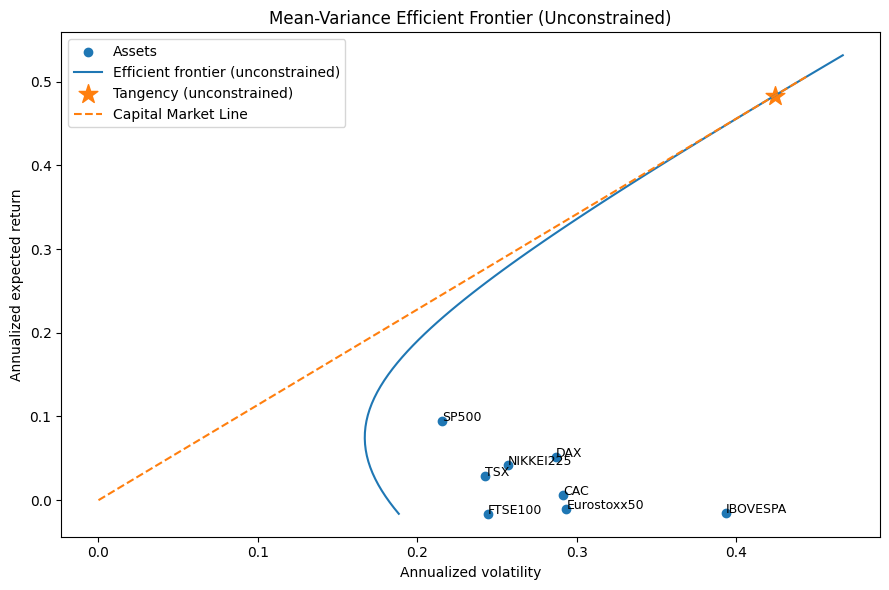

In [90]:
plt.figure(figsize=(9, 6))

# 1) Individual assets
plt.scatter(sigma_series.values, mu_series.values, label="Assets")
for i, name in enumerate(assets):
    plt.annotate(name,
                 (sigma_series.values[i], mu_series.values[i]),
                 fontsize=9)

# 2) Unconstrained efficient frontier
plt.plot(frontier_uncon[:, 1], frontier_uncon[:, 0],
         label="Efficient frontier (unconstrained)")

# 3) Tangency portfolio
plt.scatter([tan_vol_uncon], [tan_ret_uncon],
            marker="*", s=200, label="Tangency (unconstrained)")

# 4) Capital Market Line (rf = 0 => line from origin to tangency)
vol_line = np.linspace(0, tan_vol_uncon * 1.05, 50)
ret_line = (tan_ret_uncon / tan_vol_uncon) * vol_line  # slope = Sharpe_T
plt.plot(vol_line, ret_line, linestyle="--", label="Capital Market Line")

plt.title("Mean-Variance Efficient Frontier (Unconstrained)")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.legend()
plt.tight_layout()
plt.show()

The plot shows the **unconstrained Markowitz world** in one picture.

The blue dots are the individual indices $(\sigma_i, \mu_i)$. Most of them sit clearly **below** the blue efficient frontier: for the same volatility, a suitably diversified portfolio can deliver a higher expected return than any single index.

The blue curve is the **mean–variance efficient frontier** obtained from our quadratic program with  
$1^\top w = 1$ and $\mu^\top w = \mu_{\text{target}}$. The orange star is the **tangency portfolio**: it lies on the frontier and achieves the highest Sharpe ratio. Its location, far above and to the right of the indices, is consistent with the very levered long–short weights we obtained numerically.

Finally, the dashed orange line is the **Capital Market Line**. With $r_f = 0$, it runs from the origin through the tangency portfolio. Any combination of the risk-free asset and the tangency portfolio lies on this line and dominates the rest of the frontier in terms of expected return per unit of risk.

### 2.5 Efficient frontier with no short-sale constraint ($w \ge 0$)

We now recompute the mean–variance efficient frontier **imposing non-negative weights**, i.e.
$w_i \ge 0$ for all assets. The optimization problem becomes:

- fully invested: $1^\top w = 1$  
- target return: $\mu^\top w = \mu_{\text{target}}$  
- no short-selling: $w_i \ge 0$ for all $i$.

For each target return on the same grid as before, we solve the constrained
minimum-variance problem and record the corresponding portfolio return, volatility
and Sharpe ratio.

The **constrained tangency portfolio** is then defined as the portfolio on this
no-short-sale frontier that attains the **highest Sharpe ratio** (with $r_f = 0$).

Because we impose a no short-sale constraint ($w \ge 0$), not every target
return on the grid is necessarily feasible. In practice, for some high
$\mu_{\text{target}}$ the optimizer cannot find a portfolio that satisfies
simultaneously:
- $1^\top w = 1$,
- $\mu^\top w = \mu_{\text{target}}$,
- and $w_i \ge 0$ for all $i$.

We therefore solve the optimization over the whole grid of target returns and
retain only the portfolios for which the constraints admit a valid solution.

In [91]:
# Efficient frontier with no short-selling (w >= 0)
# We keep only feasible targets, and define the constrained tangency
# as the portfolio on this frontier with the highest Sharpe ratio.
frontier_noshort = []
weights_noshort = []
targets_ok = []

for t_ret in target_grid:
    try:
        w = solve_mv_target_return_quadprog(mu, Sigma, t_ret, no_short=True)
        ret, vol, sh = portfolio_stats(w, mu, Sigma, rf=rf)
        frontier_noshort.append((ret, vol, sh))
        weights_noshort.append(w)
        targets_ok.append(t_ret)
    except ValueError:
        # infeasible target under no-short constraints -> skip
        continue

frontier_noshort = np.array(frontier_noshort)
targets_ok = np.array(targets_ok)

# Tangency under no-short: pick the feasible portfolio with the highest Sharpe ratio
idx_best = np.nanargmax(frontier_noshort[:, 2])
w_tan_noshort = weights_noshort[idx_best]
tan_ret_ns, tan_vol_ns, tan_sh_ns = portfolio_stats(w_tan_noshort, mu, Sigma, rf=rf)

w_tan_noshort, tan_ret_ns, tan_vol_ns, tan_sh_ns

(array([ 5.30900506e-17, -2.55695953e-16, -1.53780126e-18,  9.62876608e-17,
         1.25196383e-01, -1.00424866e-16,  8.74803617e-01,  0.00000000e+00]),
 0.08773417759756252,
 0.19443955322941314,
 0.45121569217991214)

The tangency portfolio **with no short-selling** has the following properties:

- The weight vector is essentially long-only in two indices.  
  Numerically, we obtain  
  $$
  w_T \approx 
  (0,\ 0,\ 0,\ 0,\ 0.125,\ 0,\ 0.875,\ 0),
  $$
  up to tiny numerical rounding errors (of order $10^{-16}$).  
  
  So the constrained tangency portfolio is roughly **12.5% in NIKKEI225** and **87.5% in SP500**, with all other weights very close
  to zero. It still satisfies the budget constraint $\sum_i w_{T,i} = 1$ and
  remains fully invested, but without any leverage.

- Annualised expected return:  
  $$
  R_T \approx 8.8\%.
  $$

- Annualised volatility:  
  $$
  \sigma_T \approx 19.4\%.
  $$

- Sharpe ratio (with $r_f = 0$):  
  $$
  \text{Sharpe}_T \approx 0.45.
  $$

Compared to the **unconstrained** tangency portfolio (which was highly levered and
long–short with $\text{Sharpe} \approx 1.14$), the **no-short** tangency portfolio
is much more realistic from a practical point of view: it is long-only, far less
risky in terms of volatility and leverage, but this comes at the cost of a lower
Sharpe ratio. 

Intuitively, once short-selling is forbidden, the optimizer can no
longer exploit extreme long–short positions, and ends up concentrating on the
indices with the best standalone risk–return profile (here mainly the SP500,
with a small allocation to NIKKEI225 for diversification).

We clean the tangency weights by setting to zero all entries with absolute
value below a small numerical tolerance (e.g. $10^{-10}$), so that the
portfolio vector is easier to read. We then check that the cleaned weights
still sum to one, which confirms that the fully invested constraint
$\mathbf{1}^\top w = 1$ remains satisfied after rounding.

In [92]:
tol = 1e-10
w_tan_noshort_clean = w_tan_noshort.copy()
w_tan_noshort_clean[np.abs(w_tan_noshort_clean) < tol] = 0.0

w_tan_noshort_clean, w_tan_noshort_clean.sum()

(array([0.        , 0.        , 0.        , 0.        , 0.12519638,
        0.        , 0.87480362, 0.        ]),
 np.float64(1.0000000000000002))

In [93]:
print("Sum weights:", w_tan_noshort.sum())
print("Min weight:", w_tan_noshort.min())

Sum weights: 1.0000000000000002
Min weight: -2.5569595323416374e-16


The cleaned no-short-sale tangency portfolio has weights

$w_T \approx (0,\;0,\;0,\;0,\;0.1252,\;0,\;0.8748,\;0)$,

which means that the optimal constrained portfolio is effectively a two-asset portfolio: about $12.5\%$ in NIKKEI225 and $87.5\%$ in SP500, with zero weight on all the other indices. The cleaned weights still satisfy

$\sum_i w_i \approx 1.0000000000000002 \simeq 1$,

and the raw solution gives

$\text{Sum weights} = 1.0$, $\min_i w_i \approx -2.8 \times 10^{-16}$.

This tiny negative value is just a numerical rounding error and can safely be treated as zero, so the non-negativity constraints $w_i \ge 0$ and the fully-invested constraint $\mathbf{1}^\top w = 1$ are both satisfied in practice.

Now we clean the no-short tangency portfolio by forcing very small numerical values
to zero: any weight with absolute value below $10^{-10}$ is treated as zero. This
gets rid of tiny negative numbers that only come from floating point rounding.
We then convert the cleaned weight vector into a `pandas` Series with the asset
names as the index, so that we can clearly see how the portfolio is allocated.

In [94]:
w_tan_noshort_clean = np.where(np.abs(w_tan_noshort) < 1e-10, 0, w_tan_noshort)
w_tan_noshort_clean = pd.Series(w_tan_noshort_clean, index=assets)
w_tan_noshort_clean

TSX            0.000000
CAC            0.000000
DAX            0.000000
Eurostoxx50    0.000000
NIKKEI225      0.125196
FTSE100        0.000000
SP500          0.874804
IBOVESPA       0.000000
dtype: float64

The cleaned no–short-sale tangency portfolio allocates:

- **87.48%** of wealth to **SP500**
- **12.52%** of wealth to **NIKKEI225**
- **0%** to all other indices (TSX, CAC, DAX, Eurostoxx50, FTSE100, IBOVESPA)

In other words, the optimal constrained tangency portfolio is effectively a **two-asset long-only portfolio**, heavily tilted towards the US equity market (SP500) with a smaller satellite position in Japanese equities (NIKKEI225). This confirms that, once short-selling is ruled out, the optimizer concentrates the entire allocation on the two indices with the best risk–return trade-off in the sample.

### 2.6 Plot: unconstrained vs no-short efficient frontiers

We now put everything together in a single figure.  
We plot the individual indices using their annualized mean return and volatility, then 
overlay the two efficient frontiers:

- the unconstrained frontier (short-selling allowed), and  
- the frontier with the no short-sale constraint ($w \ge 0$).

On top of that, we mark the tangency portfolio in each case, so we can directly see how 
the shape of the frontier and the location of the optimal portfolio change once we rule 
out short positions.

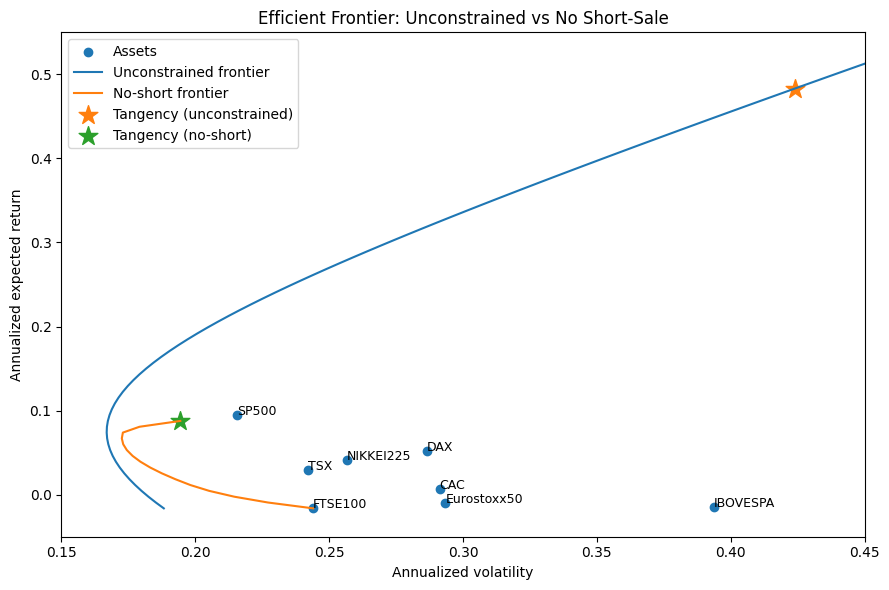

In [95]:
plt.figure(figsize=(9, 6))

# Assets
plt.scatter(sigma_series.values, mu_series.values, label="Assets")
for i, name in enumerate(assets):
    plt.annotate(name,
                 (sigma_series.values[i], mu_series.values[i]),
                 fontsize=9)

# Frontiers
plt.plot(frontier_uncon[:, 1], frontier_uncon[:, 0],
         label="Unconstrained frontier")
plt.plot(frontier_noshort[:, 1], frontier_noshort[:, 0],
         label="No-short frontier")

# Tangency points
plt.scatter([tan_vol_uncon], [tan_ret_uncon],
            marker="*", s=200, label="Tangency (unconstrained)")
plt.scatter([tan_vol_ns], [tan_ret_ns],
            marker="*", s=200, label="Tangency (no-short)")

plt.title("Efficient Frontier: Unconstrained vs No Short-Sale")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.legend()

# We keep a large scale to see both tangencies
plt.xlim(0.15, 0.45)
plt.ylim(-0.05, 0.55)

plt.tight_layout()
plt.show()

This plot compares the Markowitz world with and without short-selling.

- The **blue curve** is the unconstrained frontier. The **orange curve** is the
  no-short frontier. The blue one sits clearly **above** the orange one, which
  shows that allowing short positions (and leverage) gives strictly better
  risk–return trade-offs.

- The **orange star** (unconstrained tangency) is very far to the right, with
  high volatility and a very high expected return. This is the crazy long–short
  portfolio with large positive and negative weights we found earlier.

- The **green star** (no-short tangency) is much closer to the equity indices.
  With $w_i \ge 0$, the optimal portfolio looks like a standard long-only
  equity mix: lower volatility, lower expected return, and a lower Sharpe
  compared to the unconstrained case.

So visually we see the trade-off: allowing short-selling boosts the efficient
frontier and the Sharpe ratio, but at the cost of very extreme portfolios.

We now add a second figure to **zoom in** on the realistic region of the plot
(volatility around 15–30%, returns below 15%). On the full-scale graph, the
unconstrained tangency portfolio is so extreme that it compresses everything
else. 

The zoomed figure lets us clearly compare the unconstrained and
no-short frontiers around the indices, and see where the no-short tangency
portfolio sits relative to the actual assets.

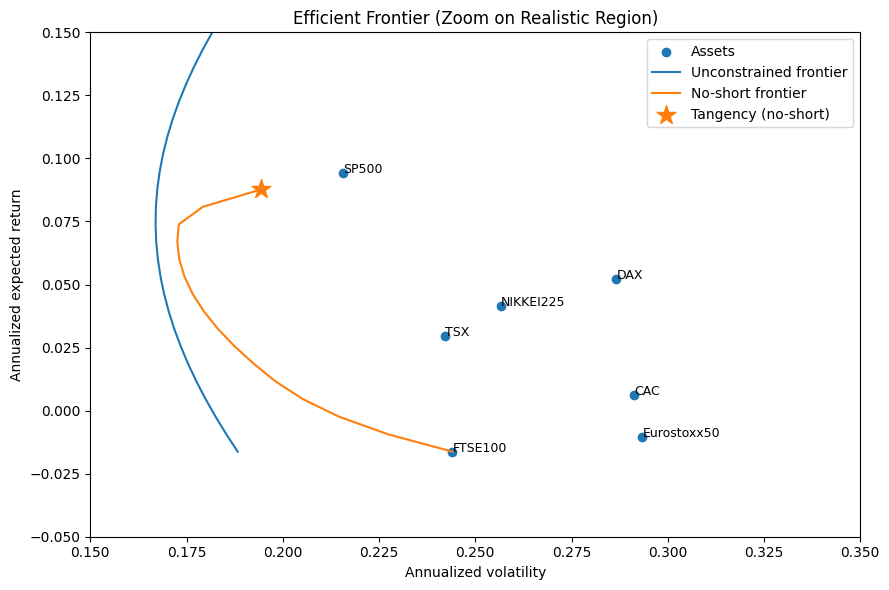

In [96]:
# Second figure: zoom on realistic region (no-short frontier and assets)
plt.figure(figsize=(9, 6))

# Assets
plt.scatter(sigma_series.values, mu_series.values, label="Assets")
for i, name in enumerate(assets):
    plt.annotate(name,
                 (sigma_series.values[i], mu_series.values[i]),
                 fontsize=9)

# Frontiers (we can keep both but the zoom value the no-short)
plt.plot(frontier_uncon[:, 1], frontier_uncon[:, 0],
         label="Unconstrained frontier")
plt.plot(frontier_noshort[:, 1], frontier_noshort[:, 0],
         label="No-short frontier")

# Tangency points

plt.scatter([tan_vol_ns], [tan_ret_ns],
            marker="*", s=200, label="Tangency (no-short)")

plt.title("Efficient Frontier (Zoom on Realistic Region)")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.legend()

# Zoom on the zone where indexes live and the tangency no-short
plt.xlim(0.15, 0.35)
plt.ylim(-0.05, 0.15)

plt.tight_layout()
plt.show()

On the zoomed plot we focus on the “realistic” region (volatility between about
15% and 35%, returns between −5% and 15%). This is why **IBOVESPA does not
appear** here: its annual volatility is around 40%, so it lies outside the
chosen $x$-axis range.

In this region we clearly see that:

- The **no-short frontier** (orange) is below the **unconstrained frontier**
  (blue), as expected: once we forbid short positions, the set of feasible
  portfolios shrinks and risk–return trade-offs become worse.

- The **no-short tangency portfolio** (orange star) sits around 19% volatility
  and 8.8% expected return. It lies above all individual indices in this zoom,
  especially above the SP500 point, which shows that a long-only combination of
  NIKKEI225 and SP500 can still dominate any single market index in terms of
  Sharpe ratio.

Overall, the zoomed figure makes it easier to compare the two frontiers and to
see that the long-only efficient set is much closer to the cloud of indices
than the extreme unconstrained frontier.

### 2.7 Portfolio weights

We now report and compare the tangency portfolio weights for:

- the unconstrained case (short-selling allowed), and  
- the no short-sale case (weights constrained to be non-negative).

This allows us to see how the no-short constraint changes the composition
and concentration of the optimal portfolio.

To make the comparison more transparent, we collect the tangency portfolio
weights in a single table. The first column reports the weights of the
unconstrained tangency portfolio (short-selling allowed), and the second
column shows the tangency portfolio when we impose the no short-sale
constraint $w_i \ge 0$. In both cases, the weights sum to one.

In [97]:
# Reminder: w_tan_uncon, w_tan_noshort et w_tan_noshort_clean already computed above

# Table of tangency portfolio weights
weights_df = pd.DataFrame({
    "Tangency_Unconstrained": w_tan_uncon,
    "Tangency_NoShort": w_tan_noshort_clean  # cleaned version (we set tiny values to 0)
}, index=assets)

# Rounded version for a better presentation!
weights_df_rounded = weights_df.round(4)
weights_df_rounded

,Tangency_Unconstrained,Tangency_NoShort
TSX,-0.4824,0.0000
CAC,3.0784,0.0000
DAX,4.0278,0.0000
Eurostoxx50,-6.6824,0.0000
NIKKEI225,0.4463,0.1252
FTSE100,-0.8347,0.0000
SP500,1.7312,0.8748
IBOVESPA,-0.2843,0.0000


We now compare the tangency portfolios with and without short-selling:

- In the **unconstrained case**, the optimizer uses very **large long and short positions**.  
  For example, it takes big long positions in **CAC** and **DAX**, but also large short
  positions in **Eurostoxx50**, **TSX**, **FTSE100** and **IBOVESPA**. The weights still sum
  to 1, but $\sum_i |w_i|$ is much larger than 1, which means the portfolio is highly
  levered. This is a typical feature of the Markowitz solution when we do not impose any
  practical constraint.

- With the **no short-sale constraint** ($w_i \ge 0$), the tangency portfolio becomes
  much simpler and more realistic: it is essentially a combination of **SP500**
  (about $87\%$) and **NIKKEI225** (about $13\%$), with zero weight on all other
  indices. Under our plug-in estimates, these two markets offer the best trade-off between
  risk and return once we rule out short positions.

Overall, the comparison clearly shows that short-selling leads to very extreme and
levered Markowitz portfolios, while the no-short constraint produces a more concentrated
but more plausible allocation.

### 2.8 Conclusion for Question 2

In this part, we used historical daily USD returns to estimate annualised means $\mu$ and the
covariance matrix $\Sigma$, and we mapped the Markowitz problem into the
`quadprog.solve_qp` format with the constraints $1^\top w = 1$ and
$\mu^\top w = \mu_{\text{target}}$. 

On this basis we traced the mean–variance efficient frontier
and found the **unconstrained tangency portfolio**, with annualised return
$R_T \approx 48.3\%$, volatility $\sigma_T \approx 42.4\%$ and Sharpe ratio
$\text{Sharpe}_T \approx 1.14$. It looks extremely attractive on paper, but it achieves this
performance by taking very large long and short positions (leverage
$\sum_i |w_i| \approx 17.6$), which would be hard to implement in practice because of margin
requirements, risk limits and typical regulations for institutional investors.

When we repeat the exercise under the **no short-sale constraint** $w_i \ge 0$, the efficient
frontier shifts down and the tangency portfolio becomes a much more realistic long-only
allocation: roughly $87.5\%$ in SP500 and $12.5\%$ in NIKKEI225, with annualised return
$R_T \approx 8.8\%$, volatility $\sigma_T \approx 19.4\%$ and Sharpe ratio
$\text{Sharpe}_T \approx 0.45$. The constrained portfolio is less “impressive’’ in terms of
Sharpe ratio, but it is far closer to what an actual fund (e.g. a pension fund with capital and
regulatory constraints) could hold. 

Overall, Question 2 shows clearly how adding simple
constraints like $w_i \ge 0$ dramatically changes both the efficient frontier and the composition
of the “optimal’’ portfolio.

## Question 3 – Mean-Variance (MV) analysis #2

In this part we repeat the mean–variance analysis using rolling 5-year windows.  
The idea is to mimic an investor who periodically re-estimates expected returns
and covariances using only the most recent 5 years of data, and then updates
their optimal portfolio.

Concretely, we start with the window from 2010–2014, then roll the window
forward one year at a time until the last window 2017–2021. For each window,
we compute the mean–variance tangency portfolio (using the same plug-in
estimates and `quadprog` mapping as in Question 2), and at the end we compare
these time-varying MV weights to the corresponding market cap-based weights.

In [98]:
# Define 5-year rolling windows by calendar year
window_years = [(2010, 2014),
                (2011, 2015),
                (2012, 2016),
                (2013, 2017),
                (2014, 2018),
                (2015, 2019),
                (2016, 2020),
                (2017, 2021)]

window_labels = [f"{start}-{end}" for (start, end) in window_years]
window_labels

['2010-2014',
 '2011-2015',
 '2012-2016',
 '2013-2017',
 '2014-2018',
 '2015-2019',
 '2016-2020',
 '2017-2021']

### 3.1 Rolling-window set-up and estimation

For each 5-year window, we:

1. Restrict the daily log-return data to that period.
2. Recompute the annualized expected returns and covariance matrix.
3. Compute the unconstrained tangency portfolio using the closed-form formula from the course notes.
4. Compute the no-short tangency portfolio by searching along the constrained efficient frontier and 
   picking the portfolio with the highest Sharpe ratio.

We then collect the weights across windows to see how unstable (or stable) the mean–variance portfolios are over time.

In [99]:
tan_uncon_weights = []
tan_noshort_weights = []
tan_uncon_stats = []   # (ret, vol, sharpe)
tan_noshort_stats = []

for (start_year, end_year), label in zip(window_years, window_labels):
    # Select 5-year window 
    start_date = f"{start_year}-01-01"
    end_date = f"{end_year}-12-31"
    window_data = returns.loc[start_date:end_date]
    
    # If for some reason window is empty, skip
    if window_data.empty:
        print(f"Warning: no data for window {label}")
        tan_uncon_weights.append(np.nan * np.ones(n))
        tan_noshort_weights.append(np.nan * np.ones(n))
        tan_uncon_stats.append((np.nan, np.nan, np.nan))
        tan_noshort_stats.append((np.nan, np.nan, np.nan))
        continue
    
    # We recompute daily mean and covariance for this window
    mu_daily_w = window_data.mean().values
    Sigma_daily_w = window_data.cov().values
    
    mu_w = mu_daily_w * ann_factor
    Sigma_w = Sigma_daily_w * ann_factor
    mu_excess_w = mu_w - rf * np.ones(n)
    
    # Unconstrained tangency (closed form)
    invSigma_w = np.linalg.inv(Sigma_w)
    numer_w = invSigma_w @ mu_excess_w
    denom_w = np.ones(n) @ numer_w
    w_tan_uncon_w = numer_w / denom_w
    
    ret_u, vol_u, sh_u = portfolio_stats(w_tan_uncon_w, mu_w, Sigma_w, rf=rf)
    
    tan_uncon_weights.append(w_tan_uncon_w)
    tan_uncon_stats.append((ret_u, vol_u, sh_u))
    
    # No-short tangency: search along constrained frontier
    target_grid_w = np.linspace(mu_w.min(), mu_w.max(), 60)
    frontier_noshort_w = []
    weights_noshort_w = []
    
    for t_ret in target_grid_w:
        try:
            w_ns = solve_mv_target_return_quadprog(mu_w, Sigma_w, t_ret, no_short=True)
            r_ns, v_ns, s_ns = portfolio_stats(w_ns, mu_w, Sigma_w, rf=rf)
            frontier_noshort_w.append((r_ns, v_ns, s_ns))
            weights_noshort_w.append(w_ns)
        except ValueError:
            # Infeasible target under no-short -> skip
            continue
    
    if len(frontier_noshort_w) == 0:
        # No feasible portfolio found (unlikely, but just in case)
        print(f"Warning: no feasible no-short solution for window {label}")
        tan_noshort_weights.append(np.nan * np.ones(n))
        tan_noshort_stats.append((np.nan, np.nan, np.nan))
    else:
        frontier_noshort_w = np.array(frontier_noshort_w)
        idx_best = np.nanargmax(frontier_noshort_w[:, 2])  # max Sharpe
        w_tan_noshort_w = weights_noshort_w[idx_best]
        r_ns, v_ns, s_ns = frontier_noshort_w[idx_best]
        
        tan_noshort_weights.append(w_tan_noshort_w)
        tan_noshort_stats.append((r_ns, v_ns, s_ns))

In this loop we basically rerun the full Markowitz procedure for each 5-year
window. For every window, we:

- recompute the annualised mean vector and covariance matrix using only the
  returns in that period;
- build an **unconstrained** tangency portfolio using the closed-form
  $\Sigma^{-1}\mu$ formula, and record its return, volatility, and Sharpe ratio;
- build a **no short-sale** tangency portfolio by scanning a grid of target
  returns, solving the quadratic program with $w \ge 0$, and keeping the
  feasible portfolio with the highest Sharpe ratio.

We store both the weights and the performance statistics for each window so we
can later turn them into DataFrames and see how these “optimal” portfolios move
over time.

### 3.2 Rolling tangency portfolios: instability and concentration

We now organise the rolling-window results into simple tables. The code below
turns the stored weight vectors and performance statistics into DataFrames,
with one row per 5-year window and one column per index (or per moment). This
makes it easier to see how the tangency portfolios and their Sharpe ratios
evolve over time, and to check how concentrated and unstable they are across
windows.

In [100]:
tan_uncon_weights_df = pd.DataFrame(tan_uncon_weights, index=window_labels, columns=assets)
tan_noshort_weights_df = pd.DataFrame(tan_noshort_weights, index=window_labels, columns=assets)

tan_uncon_stats_df = pd.DataFrame(tan_uncon_stats, 
                                  index=window_labels, 
                                  columns=["ann_return", "ann_vol", "sharpe"])
tan_noshort_stats_df = pd.DataFrame(tan_noshort_stats, 
                                    index=window_labels, 
                                    columns=["ann_return", "ann_vol", "sharpe"])

tan_uncon_weights_df, tan_noshort_weights_df
tan_uncon_weights_df.round(3), tan_noshort_weights_df.round(3)


(             TSX    CAC    DAX  Eurostoxx50  NIKKEI225  FTSE100  SP500  \
 2010-2014 -0.448 -1.038  2.196       -1.346      0.210    0.258  1.707   
 2011-2015 -2.601  0.224  3.181       -3.174      0.771    0.218  3.707   
 2012-2016 -0.740  2.337  2.649       -4.569      0.305   -0.524  1.768   
 2013-2017 -0.556  2.431  1.987       -4.182      0.253   -0.319  1.488   
 2014-2018 -2.489  9.735  4.944      -14.201      0.648   -1.118  3.180   
 2015-2019 -1.101  6.911  2.983       -9.414      0.546   -0.632  1.455   
 2016-2020 -0.440  6.160  4.921      -10.439      0.833   -1.396  1.139   
 2017-2021 -0.550  5.453  2.211       -6.922      0.633   -1.006  1.599   
 
            IBOVESPA  
 2010-2014    -0.538  
 2011-2015    -1.326  
 2012-2016    -0.226  
 2013-2017    -0.102  
 2014-2018     0.300  
 2015-2019     0.253  
 2016-2020     0.222  
 2017-2021    -0.418  ,
            TSX  CAC  DAX  Eurostoxx50  NIKKEI225  FTSE100  SP500  IBOVESPA
 2010-2014  0.0 -0.0  0.0          0.0 

The two tables show how **tangency portfolio weights** behave in each 5-year window:


- **Unconstrained tangency (first table):**  

  Weights are huge (far from ±1) and often negative. For example, in 2014–2018 the portfolio is very long CAC and DAX, very short Eurostoxx50, and strongly long SP500. This means the portfolio is **heavily levered and very unstable over time**: small changes in inputs lead to completely different long–short bets from one window to the next.

- **No-short tangency (second table):**  

  Almost all the weight goes systematically to **SP500**, with a smaller share in **NIKKEI225**. The other indices are essentially zero in every window (the “–0.0” values are just rounding). These constrained portfolios are **much more stable but very concentrated** in a couple of indices.

So, rolling the MV analysis through time clearly shows the trade-off:  
unconstrained MV gives extreme, unstable long–short portfolios, while adding a no-short constraint produces more realistic, but highly concentrated, allocations.

Before interpreting the no-short portfolios, we remove tiny numerical noise (weights of order $10^{-16}$) by setting very small coefficients to zero and rebuilding a cleaned DataFrame of long-only weights. This way, zeros really mean “no position” and the remaining weights are easier to interpret.

In [101]:
# Clean no-short weights: we just set tiny numerical values to zero
tan_noshort_weights_clean = np.where(np.abs(tan_noshort_weights_df.values) < 1e-10,
                                     0,
                                     tan_noshort_weights_df.values)

tan_noshort_weights_clean_df = pd.DataFrame(tan_noshort_weights_clean,
                                            index=tan_noshort_weights_df.index,
                                            columns=tan_noshort_weights_df.columns)

tan_noshort_weights_clean_df

,TSX,CAC,DAX,Eurostoxx50,NIKKEI225,FTSE100,SP500,IBOVESPA
2010-2014,0.0,0.0,0.0,0.0,0.123354,0.0,0.876646,0.000000
2011-2015,0.0,0.0,0.0,0.0,0.115577,0.0,0.884423,0.000000
2012-2016,0.0,0.0,0.0,0.0,0.114084,0.0,0.885916,0.000000
2013-2017,0.0,0.0,0.0,0.0,0.120050,0.0,0.879950,0.000000
2014-2018,0.0,0.0,0.0,0.0,0.065745,0.0,0.934255,0.000000
2015-2019,0.0,0.0,0.0,0.0,0.302376,0.0,0.693289,0.004335
2016-2020,0.0,0.0,0.0,0.0,0.454591,0.0,0.545220,0.000189
2017-2021,0.0,0.0,0.0,0.0,0.311639,0.0,0.688361,0.000000


The cleaned no-short tangency weights over the rolling 5-year windows show a very clear pattern:

- In **every window**, the portfolio is almost entirely split between **SP500** and **NIKKEI225**. The weight on SP500 is always between about $0.55$ and $0.93$, and the rest goes to NIKKEI225.
- All the other indices (TSX, CAC, DAX, Eurostoxx50, FTSE100) consistently have **weight $0$**.
- IBOVESPA only gets a **tiny** positive weight in 2015–2019 and 2016–2020 (around $0.4\%$ and $0.02\%$), which is basically negligible.

So the long-only tangency portfolio is very stable over time and heavily concentrated in SP500 (with NIKKEI225 as a smaller satellite position), while the other indices are never attractive enough in terms of risk–return to enter the optimal MV portfolio under the no-short constraint.

To visualise how unstable the mean–variance solution is over time, we now track
the weight of a single asset - the S&P 500 - across all 5-year windows. The plot
below shows its weight in the unconstrained tangency portfolio and in the
no-short tangency portfolio, so we can see how leverage and short-selling
change the behaviour of the optimiser through time.

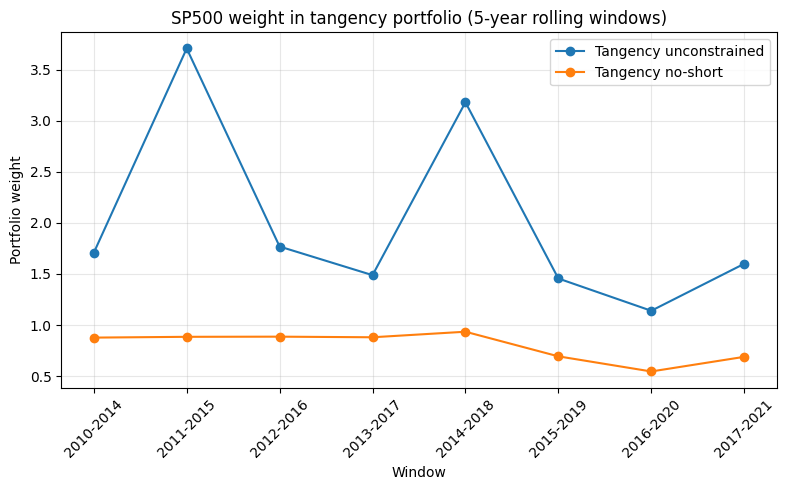

In [102]:
plt.figure(figsize=(8, 5))

# SP500 weight in unconstrained tangency portfolio
plt.plot(
    tan_uncon_weights_df.index,
    tan_uncon_weights_df["SP500"],
    marker="o",
    linestyle="-",
    label="Tangency unconstrained"
)

# SP500 weight in no-short tangency portfolio
plt.plot(
    tan_noshort_weights_clean_df.index,
    tan_noshort_weights_clean_df["SP500"],
    marker="o",
    linestyle="-",
    label="Tangency no-short"
)

plt.title("SP500 weight in tangency portfolio (5-year rolling windows)")
plt.xlabel("Window")
plt.ylabel("Portfolio weight")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The figure shows that the SP500 weight in the **unconstrained** tangency portfolio is very unstable and often well above \(1\). This means the optimiser is using leverage and short positions in the other indices to finance an oversized long position in the SP500.

By contrast, in the **no-short** tangency portfolio the SP500 weight stays between roughly \(0.55\) and \(0.95\) and moves much more smoothly across windows. The rolling exercise therefore confirms that the standard Markowitz solution is highly sample-sensitive and levered, whereas the long-only solution remains strongly tilted to the SP500 but in a more stable and realistic way.

### 3.3 Comparison with market cap-based weights

Finally, we compare our mean–variance tangency portfolios with a more
realistic benchmark: a portfolio weighted by the market capitalization
of each index. The Excel file provides these market-cap shares in the
sheet `market_cap`. We read these weights, align them with our eight
indices, and compare them to the tangency portfolios in the last
5-year window (2017-2021).

In [103]:
# Read the market_cap sheet
mkt_raw = pd.read_excel(FILE, sheet_name="market_cap", header=1)
mkt_raw.columns = [str(c).strip() for c in mkt_raw.columns]

mkt_raw

,Unnamed: 0,SPTSX INDEX,CAC INDEX,DAX INDEX,SX5E INDEX,NKY INDEX,UKX INDEX,SPX INDEX,IBOV INDEX
0,NaN,0.041834,0.04318,0.036197,0.090955,0.092523,0.081589,0.602344,0.011378


The `market_cap` sheet gives us one row of benchmark weights by index. It shows a very
concentrated universe: the S&P 500 alone represents about **60%** of total market cap,
while the other developed markets are each in the single digits, and Brazil is just a bit
above **1%**. 

Next, we rename and reorder these entries so that this market-cap portfolio can be
directly compared to our mean-variance tangency portfolios.

In [104]:
# Take the first (and only) row of weights
mkt_row = mkt_raw.iloc[0].drop(labels=["Unnamed: 0"])

# We map Excel column names to our index names
mapping = {
    "SPTSX INDEX": "TSX",
    "CAC INDEX": "CAC",
    "DAX INDEX": "DAX",
    "SX5E INDEX": "Eurostoxx50",
    "NKY INDEX": "NIKKEI225",
    "UKX INDEX": "FTSE100",
    "SPX INDEX": "SP500",
    "IBOV INDEX": "IBOVESPA",
}

mkt_weights = mkt_row.rename(index=mapping)

# We put it in order to be in the same order as "asset"
mkt_weights = mkt_weights.reindex(assets)

# We normalize just in case...
mkt_weights = mkt_weights / mkt_weights.sum()

mkt_weights

TSX            0.041834
CAC            0.043180
DAX            0.036197
Eurostoxx50    0.090955
NIKKEI225      0.092523
FTSE100        0.081589
SP500          0.602344
IBOVESPA       0.011378
Name: 0, dtype: float64

Re-expressing the Excel row as a `pandas` Series, we now have the **market-cap
weights** in exactly the same format as our other portfolios. The picture is very
skewed: the S&P 500 still dominates with about **60%** of total weight, the main
developed markets (TSX, CAC, DAX, Eurostoxx50, Nikkei, FTSE100) each get only
4–9%, and **IBOVESPA** stays tiny at just above **1%**. 

This Series is what we will now line up against the tangency portfolio weights.

To make the comparison concrete, we now focus on the last 5-year window
(2017-2021). We extract the tangency weights for that window, both with and
without short-selling, and place them side by side with the market-cap
weights in a single DataFrame. This will let us see, index by index, how far
the mean–variance portfolios are from a simple market-cap benchmark.

In [105]:
# Tangency weights in the last 5-year window (2017–2021)
w_mv_uncon_last   = tan_uncon_weights_df.loc["2017-2021"]
w_mv_noshort_last = tan_noshort_weights_clean_df.loc["2017-2021"]

# Comparison with market-cap weights
compare_weights = pd.DataFrame({
    "MarketCap": mkt_weights,  # serie built from market-cap
    "MV_Tangency_Uncon_2017_2021": w_mv_uncon_last,
    "MV_Tangency_NoShort_2017_2021": w_mv_noshort_last,
}, index=assets)

compare_weights

,MarketCap,MV_Tangency_Uncon_2017_2021,MV_Tangency_NoShort_2017_2021
TSX,0.041834,-0.549505,0.000000
CAC,0.043180,5.453498,0.000000
DAX,0.036197,2.210759,0.000000
Eurostoxx50,0.090955,-6.922410,0.000000
NIKKEI225,0.092523,0.632892,0.311639
FTSE100,0.081589,-1.006031,0.000000
SP500,0.602344,1.599128,0.688361
IBOVESPA,0.011378,-0.418332,0.000000


The table compares three sets of weights for the 2017-2021 window:

- The **market-cap portfolio** is diversified across all indices but heavily tilted to the US: about 60% in the S&P 500, with most other indices between roughly 3–9% and a tiny allocation to Brazil.

- The **unconstrained tangency portfolio** is extremely aggressive. It takes very large leveraged longs in **CAC**, **DAX** and **SP500**, financed by big short positions in **Eurostoxx50**, **FTSE100**, **TSX** and **IBOVESPA**. This is the classic Markowitz pathology when we allow unlimited short-selling and rely on noisy sample means.

- The **no short-sale tangency portfolio** is much more realistic: it puts about 69% in **SP500** and 31% in **NIKKEI225**, with zero weight on the other indices. Compared to the market-cap benchmark it is still very concentrated (mainly US + Japan), but it avoids the huge short positions and leverage of the unconstrained solution.

To visualise these differences more clearly, we now plot the three sets of
weights (market-cap, unconstrained tangency, and no-short tangency) for the
2017-2021 window on a single bar chart. This makes it easier to see, for each
index, how far the mean-variance portfolios move away from the simple
market-cap allocation.

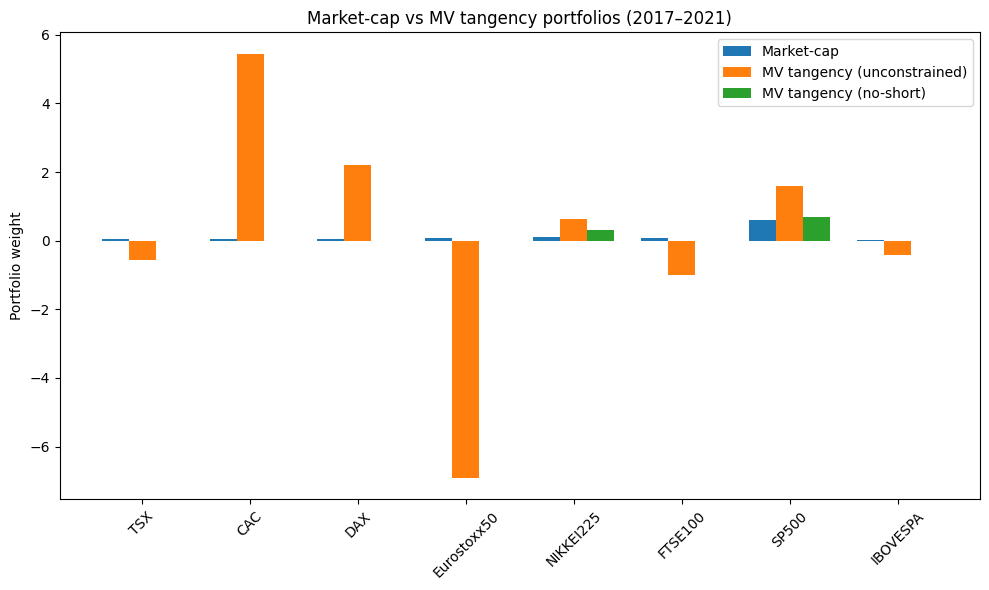

In [106]:
plt.figure(figsize=(10,6))

x = np.arange(len(assets))
width = 0.25

plt.bar(x - width, compare_weights["MarketCap"], 
        width=width, label="Market-cap")
plt.bar(x, compare_weights["MV_Tangency_Uncon_2017_2021"], 
        width=width, label="MV tangency (unconstrained)")
plt.bar(x + width, compare_weights["MV_Tangency_NoShort_2017_2021"], 
        width=width, label="MV tangency (no-short)")

plt.xticks(x, assets, rotation=45)
plt.ylabel("Portfolio weight")
plt.title("Market-cap vs MV tangency portfolios (2017–2021)")
plt.legend()
plt.tight_layout()
plt.show()

The bar chart makes the comparison very clear. The **market-cap** portfolio is
well diversified across all indices, with a dominant but not extreme weight on
the S&P 500. By contrast, the **unconstrained tangency** portfolio loads huge
long and short positions on a few indices (large long in CAC and DAX, very
large short in Eurostoxx50, etc.), which is completely unrealistic from a
practical point of view.  

The **no-short tangency** portfolio sits much closer to the market-cap
benchmark: it is still tilted towards the S&P 500 and NIKKEI225, but without
the extreme leverage and short positions. This nicely illustrates how adding a
simple non-negativity constraint can turn the theoretical Markowitz solution
into something that looks much more like a realistic equity allocation.

### 3.4 Sharpe ratios over time

So far we have focused on the portfolio **weights**. To see how meaningful these
portfolios actually are, it is also useful to track their **Sharpe ratios** over
time. For each 5-year window we already computed the tangency portfolio under:

- the **unconstrained** Markowitz model (short-selling allowed), and  
- the **no short-sale** version (weights constrained to be non-negative).

In this section we plot the Sharpe ratio of both tangency portfolios across all
rolling windows. This shows whether the very extreme unconstrained portfolios
actually deliver a consistently higher risk-adjusted performance, or whether the
more realistic no-short portfolios achieve similar Sharpe ratios with much less
leverage and concentration.

In [107]:
# Collect Sharpe ratios for each 5-year window
sharpe_df = pd.DataFrame({
    "Unconstrained": tan_uncon_stats_df["sharpe"],
    "NoShort": tan_noshort_stats_df["sharpe"],
}, index=window_labels)

sharpe_df

,Unconstrained,NoShort
2010-2014,1.995667,0.834794
2011-2015,2.061726,0.696750
2012-2016,2.053157,0.988011
2013-2017,2.086428,1.199801
2014-2018,1.484669,0.499447
2015-2019,1.731560,0.789048
2016-2020,1.519060,0.779839
2017-2021,1.534876,0.894899


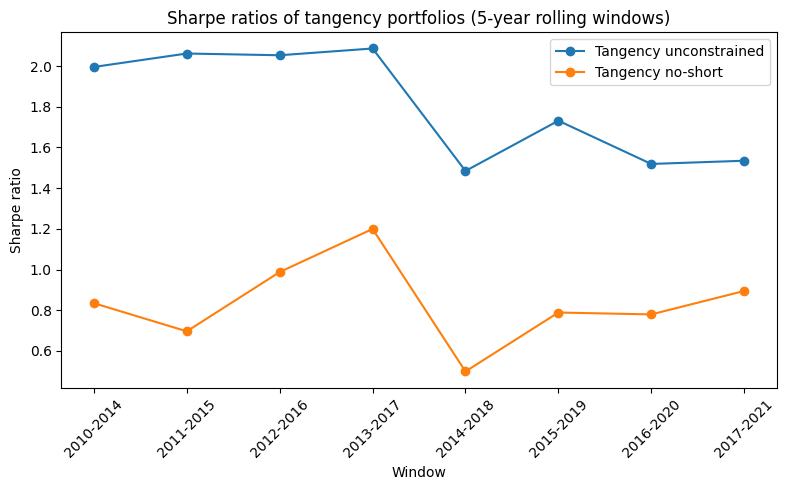

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(sharpe_df.index,
         sharpe_df["Unconstrained"],
         marker="o",
         label="Tangency unconstrained")

plt.plot(sharpe_df.index,
         sharpe_df["NoShort"],
         marker="o",
         label="Tangency no-short")

plt.title("Sharpe ratios of tangency portfolios (5-year rolling windows)")
plt.xlabel("Window")
plt.ylabel("Sharpe ratio")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The figure tracks the Sharpe ratio of the tangency portfolio in each 5-year
window, with and without short-selling.

Across all windows, the **unconstrained** portfolio delivers a higher Sharpe
ratio (around 1.5-2.1), while the **no-short** version stays in the
0.7-1.2 range. Both specifications follow a similar pattern over time:
performance is strongest in the early windows, drops sharply around
2014-2018, and then recovers.

So allowing short-selling does improve risk-adjusted performance, but the
gain is not explosive, especially compared to how extreme the unconstrained
weights are. In practice, the long-only portfolios achieve reasonably high
Sharpe ratios without requiring huge leverage.

To get a sense of how *stable* these portfolios are over time, we compute the
portfolio **turnover** between consecutive 5-year windows. 

For each strategy (unconstrained and no-short), the function `turnover` measures
$\frac{1}{2}\sum_i |w_{i,t} - w_{i,t-1}|$ between windows, so high values mean
the optimizer is radically reshuffling positions from one period to the next.  

We then compare `turn_uncon` and `turn_noshort` to see how much the
no-short constraint helps to stabilise the weights.

In [109]:
def turnover(weights_df):
    # sum of |w_t - w_{t-1}| / 2 for each window transition
    arr = weights_df.values
    to = np.abs(arr[1:] - arr[:-1]).sum(axis=1) / 2
    return pd.Series(to, index=weights_df.index[1:])

turn_uncon  = turnover(tan_uncon_weights_df)
turn_noshort = turnover(tan_noshort_weights_clean_df)

turn_uncon, turn_noshort

(2011-2015     4.808523
 2012-2016     5.073856
 2013-2017     0.994292
 2014-2018    12.750338
 2015-2019     6.660629
 2016-2020     2.885531
 2017-2021     4.366548
 dtype: float64,
 2011-2015    0.007778
 2012-2016    0.001493
 2013-2017    0.005967
 2014-2018    0.054306
 2015-2019    0.240966
 2016-2020    0.152214
 2017-2021    0.143141
 dtype: float64)

The turnover numbers confirm how unstable the unconstrained Markowitz solution is.  

For the **unconstrained tangency portfolio**, turnover is often well above 1 (and even above 10 in 2014-2018), which means the portfolio is completely reshuffled from one window to the next.  

By contrast, the **no-short tangency portfolio** has very low turnover: values stay close to zero for the early windows and only rise moderately (around 0.15–0.24) in the last years. This shows that imposing $w_i \ge 0$ not only removes extreme long–short bets, but also makes the allocation much more stable over time.

### 3.x Bonus: Risk–return comparison with the market-cap portfolio

As a final check, we compare the realised risk–return profile of three portfolios over the last window (2017-2021): the market-cap portfolio, the unconstrained tangency portfolio, and the no-short tangency portfolio. This shows whether the more “aggressive” Markowitz allocations actually deliver a better in-sample Sharpe ratio than a simple market-cap benchmark.

In [110]:
# We rcompute annualised mean and covariance for the last window (2017–2021) 
start_date = "2017-01-01"
end_date   = "2021-12-31"
window_1721 = returns.loc[start_date:end_date]

mu_daily_1721    = window_1721.mean().values
Sigma_daily_1721 = window_1721.cov().values

mu_1721    = mu_daily_1721 * ann_factor
Sigma_1721 = Sigma_daily_1721 * ann_factor

# Build the 3 portfolios' weights for that window
# mkt_weights is the Series we constructed from the 'market_cap' sheet
w_mkt_last     = mkt_weights.values                       # market-cap portfolio
w_uncon_last   = tan_uncon_weights_df.loc["2017-2021"].values      # unconstrained tangency
w_noshort_last = tan_noshort_weights_clean_df.loc["2017-2021"].values  # no-short tangency

# Compute (return, vol, Sharpe) for each
ret_mkt, vol_mkt, sh_mkt = portfolio_stats(w_mkt_last,     mu_1721, Sigma_1721, rf=rf)
ret_uc,  vol_uc,  sh_uc  = portfolio_stats(w_uncon_last,   mu_1721, Sigma_1721, rf=rf)
ret_ns,  vol_ns,  sh_ns  = portfolio_stats(w_noshort_last, mu_1721, Sigma_1721, rf=rf)

sharpe_compare = pd.DataFrame(
    {
        "ann_return": [ret_mkt, ret_uc, ret_ns],
        "ann_vol":    [vol_mkt, vol_uc, vol_ns],
        "sharpe":     [sh_mkt, sh_uc, sh_ns],
    },
    index=["MarketCap", "MV_Tangency_Uncon", "MV_Tangency_NoShort"],
)

sharpe_compare

,ann_return,ann_vol,sharpe
MarketCap,0.134005,0.175058,0.765489
MV_Tangency_Uncon,0.491154,0.319996,1.534876
MV_Tangency_NoShort,0.148207,0.165613,0.894899


The table below compares the performance of three portfolios over 2017-2021:

- **MarketCap**: annual return ≈ $13.4\%$, volatility ≈ $17.5\%$, Sharpe ≈ $0.77$.

- **Unconstrained tangency (MV\_Tangency\_Uncon)**: very high annual return (≈ $49.1\%$) but also much higher risk (volatility ≈ $32.0\%$), with a Sharpe ratio around $1.53$.

- **No-short tangency (MV\_Tangency\_NoShort)**: annual return ≈ $14.8\%$, volatility ≈ $16.6\%$, Sharpe ≈ $0.89$.

This confirms the pattern seen in the weights:

- The **unconstrained Markowitz portfolio** offers the highest Sharpe ratio, but only by taking on a lot more risk and extreme long–short positions.
- The **no-short tangency portfolio** slightly improves on the market-cap Sharpe ratio and keeps risk at a similar level, with a much more realistic, long-only allocation.
- The **market-cap portfolio** sits in between: lower efficiency than the theoretical tangency portfolio, but very reasonable risk and no leverage or short-selling.

## Conclusion

In Question 3, the rolling 5-year windows make the message very clear: the **unconstrained** tangency portfolio is extremely unstable. Small changes in estimated returns and covariances lead to big shifts in weights and high turnover from one window to the next. With the **no short-sale constraint**, the portfolios are much more stable over time and look much closer to something an actual investor could hold.

Taken together with Questions 1 and 2, the whole assignment shows the same story:  
- The data are not perfectly Gaussian or i.i.d.,  
- Unconstrained Markowitz can produce very high theoretical Sharpe ratios, but with crazy, levered, long–short positions,  
- Adding realistic constraints (like $w_i \ge 0$) and comparing to a simple market-cap portfolio brings us back to something much more sensible.

So in the end, mean–variance optimisation is a useful theoretical tool, but in practice it really needs to be combined with constraints and simple benchmarks if we want portfolios that are both *efficient on paper* and *investable in reality*.